# Predicción de Pit Stops en Fórmula 1 mediante aprendizaje autonmático

## Autores:
- César de Esteban Elvira
- Maël Humberto García
- Daniel Rodríguez Rodríguez
- Álvaro Turiégano Moreno

## Descripción
El objetivo de este trabajo es predecir si un piloto realizará un pit stop en una carrera de Fórmula 1.
Dado el estado de una vuelta concreta, el modelo debe predecir si se realizará una parada en boxes o no.

## Introducción

La Fórmula 1 es el campeonato de automovilismo más competitivo del mundo. En este deporte, la estrategia de pit stop (parada en boxes) puede marcar la diferencia entre ganar o perder una carrera.

Cada año, los equipos invierten millones de euros en infraestructura de análisis de datos para optimizar estas decisiones en tiempo real.

La aplicación del **aprendizaje automático** a la predicción de pit stops permite identificar patrones complejos que los analistas humanos podrían pasar por alto, especialmente cuando se combinan múltiples variables como la degradación de los neumático o la posición en la carrera entre otros.

Predecir cuándo un piloto realizará una parada puede ayudar a optimizar estrategias y mejorar el rendimiento.

En este trabajo utilizaremos un dataset obtenido de Kaggle: https://www.kaggle.com/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Carga del dataset

En esta sección cargamos el dataset y exploramos su estructura inicial para entender qué variables contiene.

In [26]:
df = pd.read_csv('f1_strategy_dataset_v4.csv')

print("\nPrimeras filas:")
df.head()


Primeras filas:


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,ALB,1,MEDIUM,1,2.0,17,100.625,Abu Dhabi Grand Prix,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,ALB,2,MEDIUM,1,3.0,18,93.560,Abu Dhabi Grand Prix,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,ALB,3,MEDIUM,1,4.0,18,91.768,Abu Dhabi Grand Prix,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,ALB,4,MEDIUM,1,5.0,18,91.591,Abu Dhabi Grand Prix,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,ALB,5,MEDIUM,1,6.0,18,91.422,Abu Dhabi Grand Prix,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


In [27]:
df.info()
print("\nEstadísticas descriptivas:")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 101371 entries, 0 to 101370
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  101371 non-null  str    
 1   LapNumber               101371 non-null  int64  
 2   Compound                101305 non-null  str    
 3   Stint                   101371 non-null  int64  
 4   TyreLife                101371 non-null  float64
 5   Position                101371 non-null  int64  
 6   LapTime (s)             101371 non-null  float64
 7   Race                    101371 non-null  str    
 8   Year                    101371 non-null  int64  
 9   LapTime_Delta           101371 non-null  float64
 10  Cumulative_Degradation  101371 non-null  float64
 11  PitStop                 101371 non-null  int64  
 12  PitNextLap              101371 non-null  int64  
 13  RaceProgress            101371 non-null  float64
 14  Normalized_TyreLife     101371 

,LapNumber,Stint,TyreLife,Position,LapTime (s),Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
count,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000,101371.000000
mean,30.444841,2.046394,14.549339,9.759132,92.587188,2023.589685,-0.203891,-29.550051,0.251581,0.254797,0.432618,0.386521,-0.004636
std,18.146942,0.948797,10.313385,5.406456,33.231414,1.098518,45.344910,70.235759,0.433924,0.435749,0.258129,0.259906,3.912725
min,1.000000,1.000000,1.000000,1.000000,67.012000,2022.000000,-2403.895000,-274.564000,0.000000,0.000000,0.012821,0.012821,-18.000000
25%,15.000000,1.000000,7.000000,5.000000,82.021000,2023.000000,-7.253000,-51.054500,0.000000,0.000000,0.210526,0.172414,-2.000000
50%,30.000000,2.000000,13.000000,10.000000,91.167000,2024.000000,-0.027000,-21.678000,0.000000,0.000000,0.421053,0.333333,0.000000
75%,45.000000,3.000000,20.000000,14.000000,99.356000,2025.000000,5.705000,-3.725500,1.000000,1.000000,0.631579,0.562500,2.000000
max,78.000000,8.000000,78.000000,20.000000,2526.253000,2025.000000,2433.472000,2412.431000,1.000000,1.000000,1.000000,1.000000,18.000000


## Análisis inicial

Se analizan los tipos de datos, valores nulos y estadísticas básicas del dataset para detectar posibles problemas.

### Valores nulos

Se comprueba si existen valores faltantes en el dataset, ya que pueden afectar negativamente al rendimiento de los modelos.

In [28]:
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal de filas con al menos un nulo: {df.isnull().any(axis=1).sum()}")

Valores nulos por columna:
Driver                     0
LapNumber                  0
Compound                  66
Stint                      0
TyreLife                   0
Position                   0
LapTime (s)                0
Race                       0
Year                       0
LapTime_Delta              0
Cumulative_Degradation     0
PitStop                    0
PitNextLap                 0
RaceProgress               0
Normalized_TyreLife        0
Position_Change            0
dtype: int64

Total de filas con al menos un nulo: 66


# Distribución de la variable objetivo

La varialbe objetivo es **PitStop** que indica si un piloto realiza parada en boxes mediante lo siguientes valores:

- Si PitStop = 0, no se realizada parada
- Si PitStop = 1, se realiza parada

El objetivo es construir distintos modelos capaces de predecir esta variable en función del resto de datos del dataset.

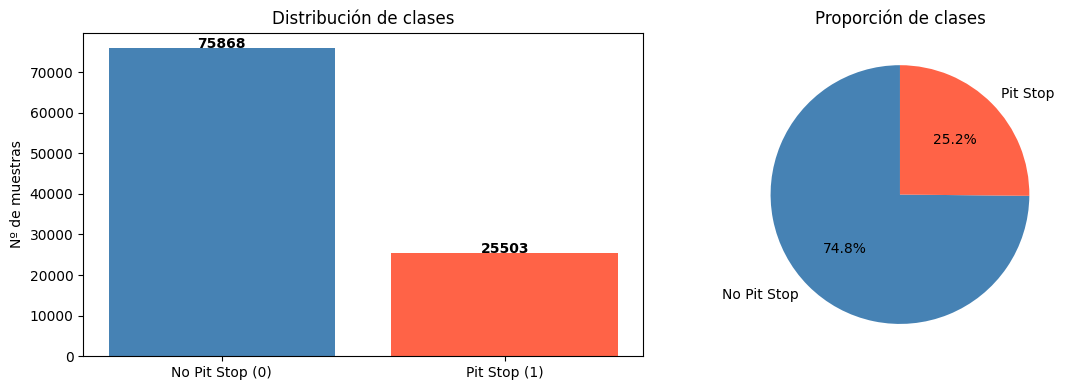


Ratio de desbalanceo: 3.0:1


In [29]:
target_col = 'PitStop'

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Conteo
counts = df[target_col].value_counts()
axes[0].bar(['No Pit Stop (0)', 'Pit Stop (1)'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('Distribución de clases')
axes[0].set_ylabel('Nº de muestras')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Porcentaje
axes[1].pie(counts.values, labels=['No Pit Stop', 'Pit Stop'],
            autopct='%1.1f%%', colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Proporción de clases')

plt.tight_layout()
plt.savefig('distribucion_clases.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nRatio de desbalanceo: {counts[0]/counts[1]:.1f}:1")

## Limpieza y preprocesamiento de datos

En esta sección se realiza la limpieza y transformación del dataset con el objetivo de preparar los datos para su uso en modelos de aprendizaje automático.

Este proceso incluye el tratamiento de valores nulos, la eliminación de duplicados y la codificación de variables categóricas.

In [30]:
df_clean = df.copy()

# Convertir columnas str a object para que fillna las detecte
df_clean = df_clean.astype({col: 'object' for col in df_clean.select_dtypes(include='string').columns})
df_clean[['Driver', 'Compound', 'Race']] = df_clean[['Driver', 'Compound', 'Race']].astype('object')

### Eliminación de duplicados

Se eliminan las filas duplicadas del dataset para evitar redundancia en la información y posibles sesgos en el entrenamiento del modelo.

La presencia de duplicados puede provocar que ciertos patrones tengan más peso del debido.

In [31]:
n_dup = df_clean.duplicated().sum()
print(f"Duplicados eliminados: {n_dup}")
df_clean.drop_duplicates(inplace=True)

Duplicados eliminados: 0


### Tratamiento de valores nulos

Los valores nulos se gestionan de forma diferente según el tipo de variable:

- **Variables numéricas**: se rellenan con la mediana, ya que es una medida robusta frente a valores atípicos.
- **Variables categóricas**: se rellenan con la moda, es decir, el valor más frecuente.

Este enfoque permite mantener la mayor cantidad de información posible sin introducir sesgos significativos.

In [32]:
num_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
for col in num_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"  '{col}': {df_clean[col].isnull().sum()} nulos → rellenado con mediana ({median_val:.2f})")

cat_cols = ['Driver', 'Compound', 'Race']
for col in cat_cols:
    if df_clean[col].isna().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col] = df_clean[col].fillna(mode_val)
        print(f"  '{col}': rellenado con moda ('{mode_val}')")

print(f"\nNulos restantes: {df_clean.isnull().sum().sum()}")

  'Compound': rellenado con moda ('HARD')

Nulos restantes: 0


### Codificación de variables categóricas

Los modelos de aprendizaje automático requieren que todas las variables sean numéricas. Por este motivo, las variables categóricas se transforman mediante **Label Encoding**.

Este método asigna un valor numérico único a cada categoría, permitiendo que los algoritmos puedan procesarlas correctamente.

In [33]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
for col in cat_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f"Columna '{col}' codificada.")

df_clean.head()

Columna 'Driver' codificada.
Columna 'Compound' codificada.
Columna 'Race' codificada.


,Driver,LapNumber,Compound,Stint,TyreLife,Position,LapTime (s),Race,Year,LapTime_Delta,Cumulative_Degradation,PitStop,PitNextLap,RaceProgress,Normalized_TyreLife,Position_Change
0,0,1,2,1,2.0,17,100.625,0,2023,0.000,0.000,0,0,0.017241,0.117647,0.0
1,0,2,2,1,3.0,18,93.560,0,2023,-7.065,-7.065,0,0,0.034483,0.176471,-1.0
2,0,3,2,1,4.0,18,91.768,0,2023,-1.792,-8.857,0,0,0.051724,0.235294,0.0
3,0,4,2,1,5.0,18,91.591,0,2023,-0.177,-9.034,0,0,0.068966,0.294118,0.0
4,0,5,2,1,6.0,18,91.422,0,2023,-0.169,-9.203,0,0,0.086207,0.352941,0.0


### Análisis de correlaciones

Se calcula la matriz de correlación entre variables numéricas con el objetivo de identificar relaciones entre ellas.

Este análisis permite:
- Detectar variables altamente correlacionadas
- Identificar posibles redundancias
- Comprender mejor la estructura del dataset

El mapa de calor facilita la visualización de estas relaciones.

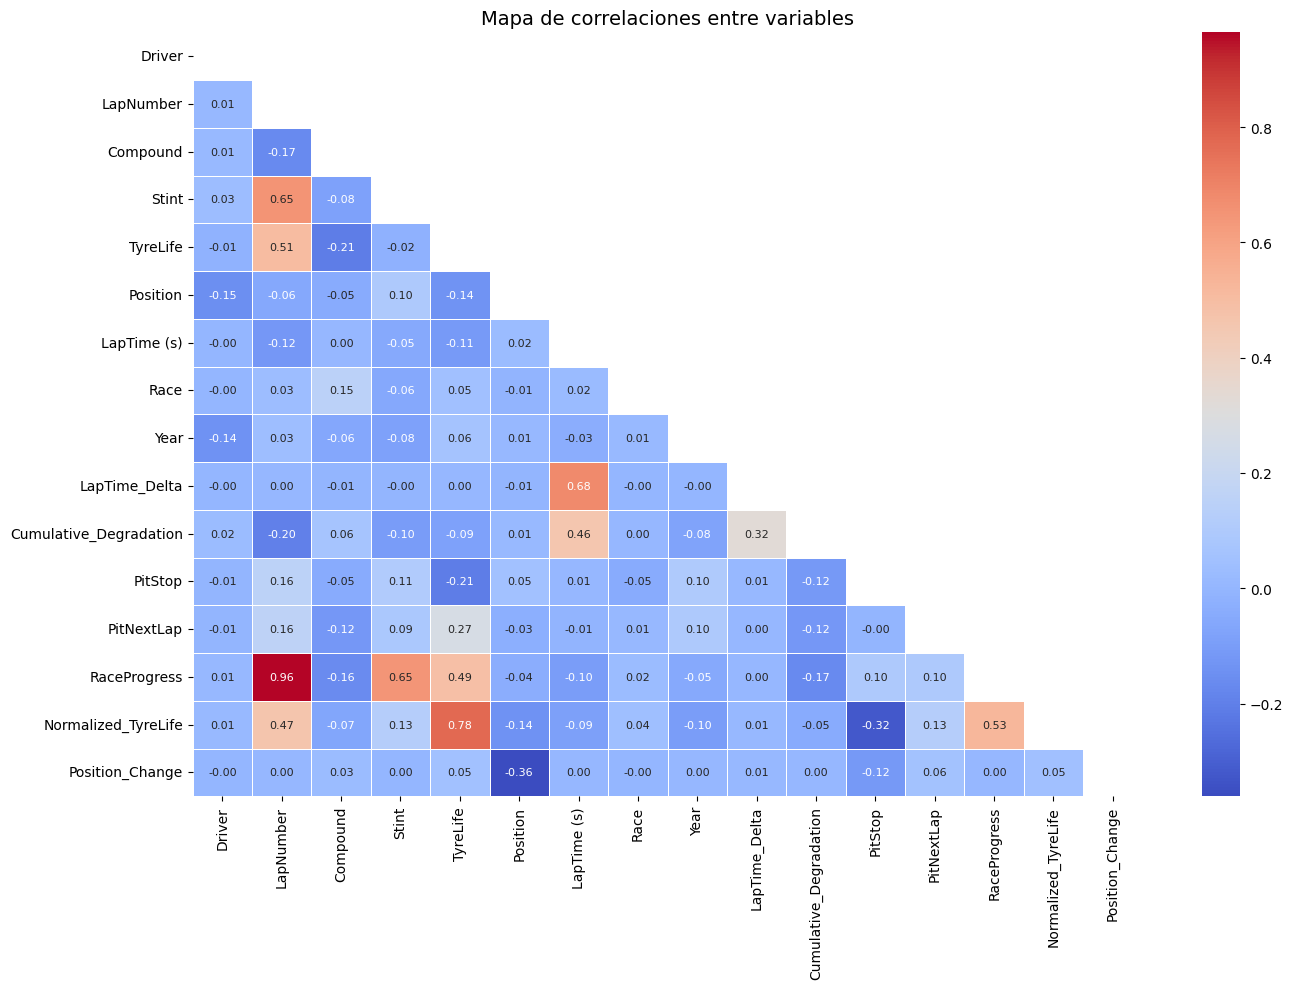

In [34]:
plt.figure(figsize=(14, 10))
#corr = df_clean.corr()
corr = df_clean.select_dtypes(include=[np.number]).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Mapa de correlaciones entre variables', fontsize=14)
plt.tight_layout()
plt.savefig('correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()

### Análisis visual de variables clave

Se realiza un análisis visual de algunas variables relevantes del dataset para entender mejor su comportamiento:

- **Vida del neumático (TyreLife)** en función del compuesto utilizado
- **Tiempo de vuelta medio (LapTime)** según la posición en carrera

Este análisis permite identificar patrones que pueden ser útiles para la predicción del pit stop.

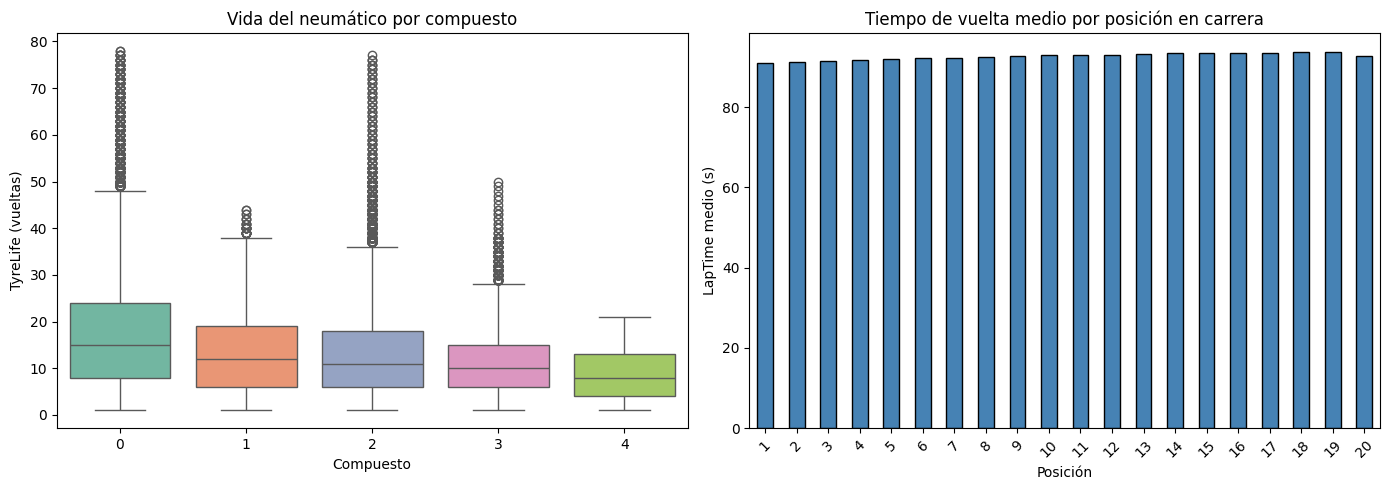

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: vida del neumático por compuesto
sns.boxplot(x='Compound', y='TyreLife', data=df_clean, ax=axes[0],
            palette='Set2')
axes[0].set_title('Vida del neumático por compuesto')
axes[0].set_xlabel('Compuesto')
axes[0].set_ylabel('TyreLife (vueltas)')

# LapTime medio por posición
df_clean.groupby('Position')['LapTime (s)'].mean().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Tiempo de vuelta medio por posición en carrera')
axes[1].set_xlabel('Posición')
axes[1].set_ylabel('LapTime medio (s)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('eda_variables.png', dpi=150, bbox_inches='tight')
plt.show()

A partir del análisis exploratorio se pueden observar ciertas tendencias en los datos, como la relación entre el tipo de neumático y su duración, o la influencia de la posición en el tiempo de vuelta.

Estos patrones sugieren que estas variables pueden ser relevantes para el modelo de predicción.

## Ingeniería de características y preparación de datos

En esta sección se preparan los datos para su uso en modelos de aprendizaje automático. Este proceso incluye la separación de variables, la división en conjuntos de entrenamiento y prueba, el escalado de las características y el tratamiento del desbalanceo de clases.

Estos pasos son fundamentales para garantizar que los modelos aprendan correctamente y generalicen adecuadamente a nuevos datos.

### Separación de variables

Se separa el dataset en:

- **Variables independientes (X)**: contienen las características utilizadas para la predicción.
- **Variable objetivo (y)**: corresponde a la variable *PitStop*, que indica si el piloto realiza una parada.

Esta separación es necesaria para poder entrenar los modelos de forma supervisada.

In [36]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print(f"Features: {X.shape[1]} columnas")
print(f"Muestras: {X.shape[0]}")
print(f"Clase 0 (no pit): {(y==0).sum()} | Clase 1 (pit): {(y==1).sum()}")

Features: 15 columnas
Muestras: 101371
Clase 0 (no pit): 75868 | Clase 1 (pit): 25503


### División en conjunto de entrenamiento y prueba

El dataset se divide en dos subconjuntos:

- **Entrenamiento (80%)**: utilizado para entrenar los modelos.
- **Prueba (20%)**: utilizado para evaluar el rendimiento final del modelo.

Se utiliza una división estratificada (*stratify*) para mantener la proporción de clases en ambos conjuntos.

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

### Escalado de variables

Se aplica una normalización mediante **StandardScaler**, que transforma las variables para que tengan media 0 y desviación estándar 1.

Este paso es especialmente importante para modelos sensibles a la escala de los datos, como SVM o redes neuronales.

In [38]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

### Tratamiento del desbalanceo de clases (SMOTE)

Dado que la variable objetivo presenta un desbalanceo entre clases, se aplica la técnica **SMOTE**.

SMOTE genera nuevas muestras sintéticas de la clase minoritaria, equilibrando el dataset y evitando que el modelo favorezca la clase mayoritaria.

Este paso es clave para mejorar la capacidad del modelo de detectar correctamente los pit stops.

In [39]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)
print(f"\nTras SMOTE — Clase 0: {(y_train_sm==0).sum()} | Clase 1: {(y_train_sm==1).sum()}")


Tras SMOTE — Clase 0: 60694 | Clase 1: 60694


## Experimentación con modelos

En esta sección se entrenan y comparan diferentes algoritmos de aprendizaje automático con el objetivo de identificar el modelo que mejor se adapta al problema.

Se han seleccionado los siguientes modelos:

- **Regresión Logística**: modelo lineal de clasificación que permite establecer una referencia inicial de rendimiento.
- **KNN**: algoritmo basado en instancias que clasifica cada ejemplo en función de los vecinos más cercanos.
- **Árbol de Decisión**: modelo interpretable.
- **Random Forest**: método ensemble que reduce la varianza combinando múltiples árboles.
- **SVM**: eficaz en espacios de alta dimensión. (TARDA MUCHO, HAY QUE REDUCIR SU TIEMPO DE EJECUCIÓN DE ALGUNA FORMA)
- **Red Neuronal (MLP)**: modelo capaz de capturar relaciones no lineales complejas.

Cada modelo presenta ventajas e inconvenientes en términos de interpretabilidad, coste computacional y capacidad de generalización.

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score, roc_curve)

models = {
    'Regresión Logística': LogisticRegression(max_iter=1000, random_state=42),
    'KNN':                 KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Árbol de Decisión': DecisionTreeClassifier(max_depth=8, random_state=42),
    'Random Forest':      RandomForestClassifier(n_estimators=150, max_depth=10,
                                                 random_state=42, n_jobs=-1),
    #'SVM':                SVC(kernel='rbf', C=1.0, probability=True, random_state=42),
    'Red Neuronal (MLP)': MLPClassifier(hidden_layer_sizes=(50,), max_iter=200,
                                        random_state=42, early_stopping=True)
}

### Validación cruzada

Para evaluar el rendimiento de los modelos se utiliza **validación cruzada estratificada con 5 particiones (5-fold)**.

Este método permite obtener una estimación más robusta del rendimiento, ya que el modelo se entrena y evalúa en diferentes subconjuntos de los datos.

Además, se emplean múltiples métricas de evaluación:
- **Accuracy**: de cada 100 predicciones, cuántas acertaste en total.
- **Precision**: mide que no haya falsas alarmas (de todos los pit stops que el modelo predijo, cuántos eran realmente pit stops).
- **Recall**: Mide que no se escape ningun pit-stop (de todos los pit stops que realmente ocurrieron, cuántos detectó el modelo).
- **F1**: media armónica entre Precision y Recall. Es la métrica principal cuando hay desbalance de clases, ya que penaliza los modelos que sacrifican una métrica por la otra.
- **ROC-AUC**: mide la capacidad del modelo de distinguir entre pitstop y no pitstop independientemente del umbral de decisión. Va de 0.5 (aleatorio) a 1.0 (perfecto).

Esto permite analizar el comportamiento del modelo desde diferentes perspectivas.

In [41]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted', 'roc_auc']

### Evaluación de modelos

Cada modelo se entrena utilizando los datos balanceados con SMOTE y se evalúa mediante validación cruzada.

Posteriormente, se calcula la media de cada métrica para comparar el rendimiento de los modelos de forma objetiva.

In [42]:
cv_results = {}
for name, model in models.items():
    print(f"Entrenando: {name}...")
    scores = cross_validate(model, X_train_sm, y_train_sm, cv=cv,
                            scoring=scoring, n_jobs=-1)
    cv_results[name] = {
        'Accuracy':  scores['test_accuracy'].mean(),
        'Precision': scores['test_precision_weighted'].mean(),
        'Recall':    scores['test_recall_weighted'].mean(),
        'F1':        scores['test_f1_weighted'].mean(),
        'ROC-AUC':   scores['test_roc_auc'].mean(),
    }
    print(f"  F1: {cv_results[name]['F1']:.4f} | AUC: {cv_results[name]['ROC-AUC']:.4f}")

Entrenando: Regresión Logística...
  F1: 0.7830 | AUC: 0.8578
Entrenando: KNN...
  F1: 0.9704 | AUC: 0.9939
Entrenando: Árbol de Decisión...
  F1: 0.8199 | AUC: 0.8958
Entrenando: Random Forest...
  F1: 0.8724 | AUC: 0.9467
Entrenando: Red Neuronal (MLP)...
  F1: 0.8601 | AUC: 0.9323


In [43]:
results_df = pd.DataFrame(cv_results).T.round(4)
results_df = results_df.sort_values('F1', ascending=False)
#print("\n── Resultados validación cruzada (5-fold) ──")
#print(results_df.to_string())
results_df

,Accuracy,Precision,Recall,F1,ROC-AUC
KNN,0.9705,0.9711,0.9705,0.9704,0.9939
Random Forest,0.8726,0.8746,0.8726,0.8724,0.9467
Red Neuronal (MLP),0.8602,0.8614,0.8602,0.8601,0.9323
Árbol de Decisión,0.8201,0.8214,0.8201,0.8199,0.8958
Regresión Logística,0.7830,0.7832,0.7830,0.7830,0.8578


### Matrices de confusión

La matriz de confusión muestra el desglose completo de las predicciones de cada modelo, permitiendo ver exactamente dónde falla cada uno:

- **Verdaderos Negativos (TN)**: predijo "No Pit Stop" y era correcto
- **Falsos Positivos (FP)**: predijo "Pit Stop" pero era "No Pit Stop" (falsa alarma)
- **Falsos Negativos (FN)**: predijo "No Pit Stop" pero era "Pit Stop" (pit stop no detectado)
- **Verdaderos Positivos (TP)**: predijo "Pit Stop" y era correcto

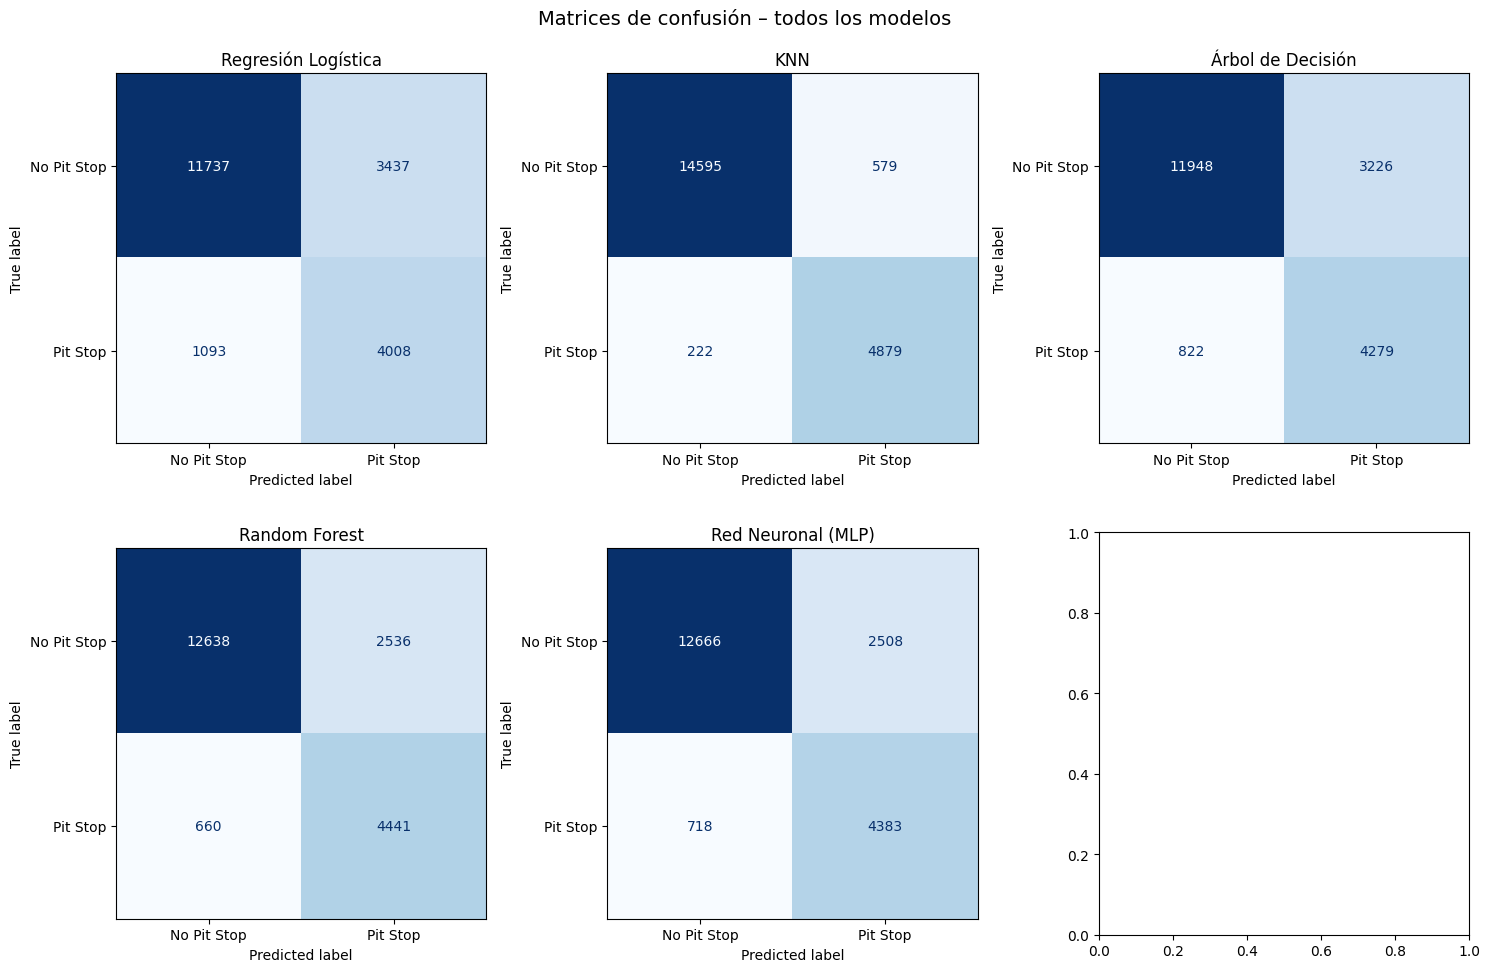

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))  # 2 filas x 3 cols para 6 modelos
axes = axes.flatten()

for i, (name, model) in enumerate(models.items()):
    model.fit(X_train_sm, y_train_sm)
    y_pred = model.predict(X_test_sc)
    
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Pit Stop', 'Pit Stop'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(name)

plt.suptitle('Matrices de confusión – todos los modelos', fontsize=14)
plt.tight_layout()
plt.savefig('matrices_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

### Visualización de resultados

Se representan gráficamente las métricas obtenidas por cada modelo, lo que facilita la comparación visual y la identificación del modelo con mejor rendimiento.

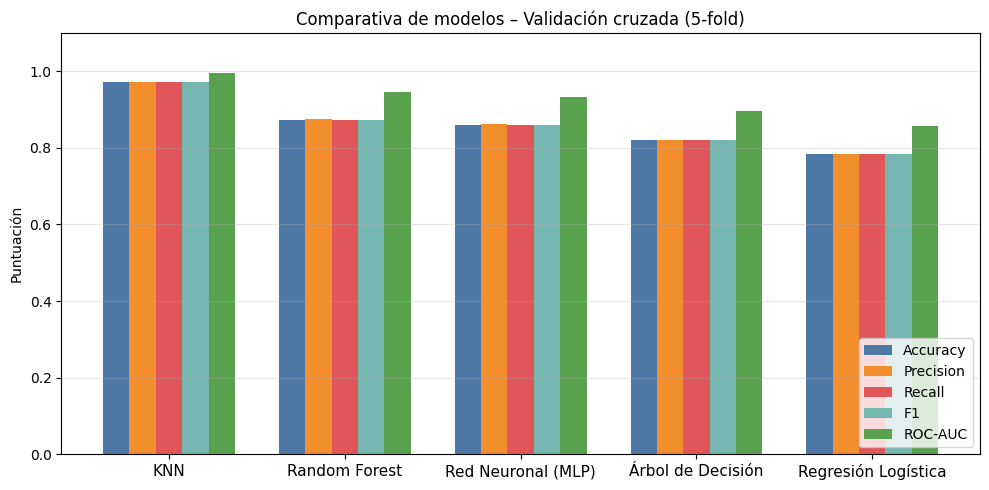

In [45]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(results_df))
width = 0.15
metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    ax.bar(x + i * width, results_df[metric], width, label=metric, color=color)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Puntuación')
ax.set_title('Comparativa de modelos – Validación cruzada (5-fold)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

A partir de la comparación de métricas, se puede identificar qué modelo presenta un mejor equilibrio entre precisión, recall y capacidad de generalización.

Este análisis será clave para la selección del modelo final.

## Resultados

En esta sección se presentan los resultados obtenidos por los diferentes modelos tras la validación cruzada, así como la evaluación final del mejor modelo sobre el conjunto de test.

### Comparación y evaluación de los modelos

Los resultados obtenidos mediante validación cruzada permiten comparar el rendimiento de los distintos algoritmos utilizando métricas como Accuracy, Precision, Recall, F1-score y ROC-AUC.

El mejor modelo obtenido en la fase de validación cruzada se entrena con todo el conjunto de entrenamiento y se evalúa sobre el conjunto de test.

Esto permite obtener una estimación final del rendimiento del modelo en datos no vistos.

In [46]:
# ── Entrenar el mejor modelo sobre train completo y evaluar en test ────────────
best_name = results_df.index[0]
best_model = models[best_name]
best_model.fit(X_train_sm, y_train_sm)
y_pred = best_model.predict(X_test_sc)
y_prob = best_model.predict_proba(X_test_sc)[:, 1]

print(f"═══ MEJOR MODELO: {best_name} ═══\n")
print(classification_report(y_test, y_pred,
                             target_names=['No Pit Stop', 'Pit Stop']))

═══ MEJOR MODELO: KNN ═══

              precision    recall  f1-score   support

 No Pit Stop       0.99      0.96      0.97     15174
    Pit Stop       0.89      0.96      0.92      5101

    accuracy                           0.96     20275
   macro avg       0.94      0.96      0.95     20275
weighted avg       0.96      0.96      0.96     20275



### Interpretación de resultados

Se analizan las métricas obtenidas junto con la matriz de confusión y la curva ROC para evaluar el comportamiento del modelo.

Estas métricas permiten analizar no solo la precisión global, sino también la capacidad del modelo para detectar correctamente la clase minoritaria (pit stop).

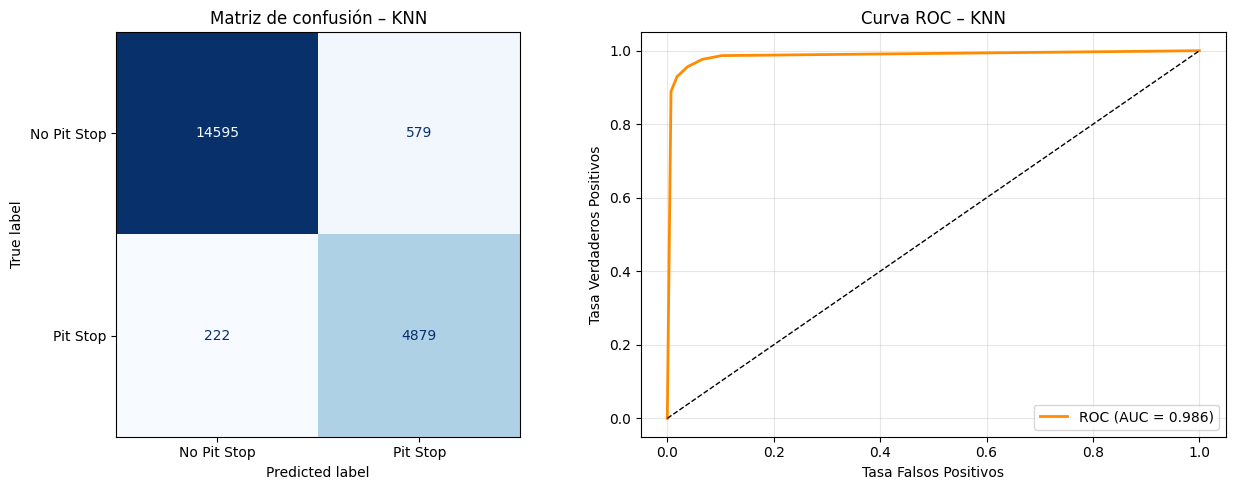

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Pit Stop', 'Pit Stop'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Matriz de confusión – {best_name}')

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].set_xlabel('Tasa Falsos Positivos')
axes[1].set_ylabel('Tasa Verdaderos Positivos')
axes[1].set_title(f'Curva ROC – {best_name}')
axes[1].legend(loc='lower right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('resultados_mejor_modelo.png', dpi=150, bbox_inches='tight')
plt.show()

### Importancia de variables

En los modelos basados en árboles se analiza la importancia de las variables para identificar cuáles tienen mayor influencia en la predicción del pit stop.

Este análisis permite interpretar el modelo y entender qué factores influyen más en la decisión.

In [48]:
if hasattr(best_model, 'feature_importances_'):
    # Árbol, Random Forest
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    top15 = importances.nlargest(15).sort_values()
    titulo = f'Top 15 variables más importantes – {best_name}'

elif hasattr(best_model, 'coef_'):
    # Regresión Logística
    importances = pd.Series(best_model.coef_[0], index=X.columns).abs()
    top15 = importances.nlargest(15).sort_values()
    titulo = f'Top 15 variables más influyentes (|coef|) – {best_name}'

else:
    top15 = None
    titulo = None

if top15 is not None:
    plt.figure(figsize=(8, 6))
    top15.plot(kind='barh', color='steelblue')
    plt.title(titulo)
    plt.xlabel('Importancia')
    plt.tight_layout()
    plt.savefig('importancia_variables.png', dpi=150, bbox_inches='tight')
    plt.show()